In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [1]:
import pandas as pd
import numpy as np
import csv
import pickle
import copy
import re
import random
import matplotlib.pyplot as plt
import itertools
import json
import openai
import time

!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.6 MB/s eta 0:00:00
time: 252 µs (started: 2026-01-06 20:04:46 +00:00)


In [2]:
!rm -rf LLM4BEAR
!git clone --depth 1 --filter=blob:none --sparse https://github.com/anon5159753/LLM4BEAR.git
!cd LLM4BEAR && git sparse-checkout set "BundleRec Data"
!cd LLM4BEAR && git sparse-checkout add "3_Human Evaluation"

Cloning into 'LLM4BEAR'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 27 (delta 1), reused 17 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 19.95 KiB | 3.99 MiB/s, done.
Resolving deltas: 100% (1/1), done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 67 bytes | 67.00 KiB/s, done.
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 82 (delta 7), reused 81 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 46.13 MiB | 8.62 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Updating files: 100% (83/83), done.
remote: Enumerating objects: 440, done.
remote: Counting objects: 100% (440/440), done.
remote: Compressing object

In [3]:
clothing_forms = [1, 3, 4, 5, 6, 7, 10, 11, 13, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 29, 30, 31, 32, 33, 34, 35, 37, 38]
electronic_forms = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 39]
food_forms = [1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15, 19, 20, 21, 23, 24, 27, 28, 31, 33, 34, 35, 36, 37, 38]

print(len(clothing_forms))
print(len(electronic_forms))
print(len(food_forms))

print("total participants:", len(clothing_forms) + len(electronic_forms) + len(food_forms))

28
33
26
total participants: 87
time: 1.35 ms (started: 2026-01-06 20:06:11 +00:00)


In [5]:
clothing_decision = []
clothing_bundle_1_scores = []
clothing_bundle_2_scores = []


for i in clothing_forms:

    PATH = f"/content/LLM4BEAR/3_Human Evaluation/forms/results_clothing_{i}.csv"

    clothing_form = pd.read_csv(PATH)

    clothing_form.head()


    decision = []
    bundle_1_scores = []
    bundle_2_scores = []

    for i in range(60):
        if i % 3 == 0:
            if clothing_form.iloc[0, i] == "Bundle 1 is better":
                decision.append(1)
            elif clothing_form.iloc[0, i] == "Bundle 2 is better":
                decision.append(2)
        elif i % 3 == 1:
            bundle_1_scores.append(clothing_form.iloc[0, i])
        else:
            bundle_2_scores.append(clothing_form.iloc[0, i])

    clothing_decision.append(decision)
    clothing_bundle_1_scores.append(bundle_1_scores)
    clothing_bundle_2_scores.append(bundle_2_scores)



clothing_randomise = []


for i in clothing_forms:


    PATH = f"/content/LLM4BEAR/3_Human Evaluation/randomise_mapping/clothing_batch_{i}_randomise_map.csv"



    clothing_random = pd.read_csv(PATH)

    clothing_random.head()

    randomise = []

    for i in range(20):
        randomise.append(clothing_random.iloc[i, 2])

    clothing_randomise.append(randomise)


clothing_better = []
clothing_unmodded_scores = []
clothing_modded_scores = []

for i in range(len(clothing_randomise)):

    randomise_map = clothing_randomise[i]


    initial_decision = clothing_decision[i]
    bundle_1_scores = clothing_bundle_1_scores[i]
    bundle_2_scores = clothing_bundle_2_scores[i]

    better = 0
    unmodded_scores = []
    modded_scores = []

    for j in range(20):

        if randomise_map[j] == "yes": # means that the scores are randomised
            modded_scores.append(bundle_1_scores[j])
            unmodded_scores.append(bundle_2_scores[j])
            if initial_decision[j] == 1:
                better += 1

        elif randomise_map[j] == "no":
            modded_scores.append(bundle_2_scores[j])
            unmodded_scores.append(bundle_1_scores[j])
            if initial_decision[j] == 2:
                better += 1

    clothing_better.append(better)

    clothing_unmodded_scores.append(unmodded_scores)
    clothing_modded_scores.append(modded_scores)

higher = 0

for i in clothing_better:
    if i >= 10:
        higher += 1

print(higher, "/", len(clothing_better))

avg_unmodded_scores = [np.mean(clothing_unmodded_scores[i]) for i in range(len(clothing_unmodded_scores))]
avg_modded_scores = [np.mean(clothing_modded_scores[i]) for i in range(len(clothing_modded_scores))]

print("Unmodded Scores", avg_unmodded_scores)
print("Modded Scores", avg_modded_scores)

score_improve = 0

for i in range(len(clothing_better)):
    avg_mod = avg_modded_scores[i]
    avg_unmod = avg_unmodded_scores[i]


    if avg_mod > avg_unmod:
        score_improve += 1

print(score_improve, "/", len(clothing_better))


20 / 28
Unmodded Scores [np.float64(3.0), np.float64(1.95), np.float64(3.1), np.float64(3.05), np.float64(4.1), np.float64(2.15), np.float64(2.55), np.float64(3.5), np.float64(2.05), np.float64(3.3), np.float64(2.7), np.float64(2.85), np.float64(3.6), np.float64(1.85), np.float64(2.55), np.float64(3.65), np.float64(3.3), np.float64(3.65), np.float64(2.95), np.float64(3.05), np.float64(2.8), np.float64(1.75), np.float64(2.5), np.float64(3.55), np.float64(3.15), np.float64(3.3), np.float64(3.45), np.float64(3.6)]
Modded Scores [np.float64(2.75), np.float64(2.45), np.float64(4.1), np.float64(3.55), np.float64(4.5), np.float64(3.05), np.float64(3.35), np.float64(4.7), np.float64(2.35), np.float64(3.65), np.float64(3.8), np.float64(3.85), np.float64(3.85), np.float64(3.2), np.float64(3.15), np.float64(3.65), np.float64(4.4), np.float64(3.6), np.float64(2.95), np.float64(2.55), np.float64(3.2), np.float64(2.55), np.float64(3.4), np.float64(2.8), np.float64(3.3), np.float64(4.1), np.float64(3

In [7]:
electronic_decision = []
electronic_bundle_1_scores = []
electronic_bundle_2_scores = []


for i in electronic_forms:

    PATH = f"/content/LLM4BEAR/3_Human Evaluation/forms/results_electronic_{i}.csv"

    electronic_form = pd.read_csv(PATH)

    electronic_form.head()


    decision = []
    bundle_1_scores = []
    bundle_2_scores = []

    for i in range(60):
        if i % 3 == 0:
            if electronic_form.iloc[0, i] == "Bundle 1 is better":
                decision.append(1)
            elif electronic_form.iloc[0, i] == "Bundle 2 is better":
                decision.append(2)
        elif i % 3 == 1:
            bundle_1_scores.append(electronic_form.iloc[0, i])
        else:
            bundle_2_scores.append(electronic_form.iloc[0, i])

    electronic_decision.append(decision)
    electronic_bundle_1_scores.append(bundle_1_scores)
    electronic_bundle_2_scores.append(bundle_2_scores)



electronic_randomise = []


for i in electronic_forms:


    PATH = f"/content/LLM4BEAR/3_Human Evaluation/randomise_mapping/electronics_batch_{i}_randomise_map.csv"



    electronic_random = pd.read_csv(PATH)

    electronic_random.head()

    randomise = []

    for i in range(20):
        randomise.append(electronic_random.iloc[i, 2])

    electronic_randomise.append(randomise)


electronic_better = []
electronic_unmodded_scores = []
electronic_modded_scores = []

for i in range(len(electronic_randomise)):

    randomise_map = electronic_randomise[i]


    initial_decision = electronic_decision[i]
    bundle_1_scores = electronic_bundle_1_scores[i]
    bundle_2_scores = electronic_bundle_2_scores[i]

    better = 0
    unmodded_scores = []
    modded_scores = []

    for j in range(20):

        if randomise_map[j] == "yes": # means that the scores are randomised
            modded_scores.append(bundle_1_scores[j])
            unmodded_scores.append(bundle_2_scores[j])
            if initial_decision[j] == 1:
                better += 1

        elif randomise_map[j] == "no":
            modded_scores.append(bundle_2_scores[j])
            unmodded_scores.append(bundle_1_scores[j])
            if initial_decision[j] == 2:
                better += 1

    electronic_better.append(better)

    electronic_unmodded_scores.append(unmodded_scores)
    electronic_modded_scores.append(modded_scores)

higher = 0

for i in electronic_better:
    if i >= 10:
        higher += 1

print(higher, "/", len(electronic_better))



avg_unmodded_scores = [np.mean(electronic_unmodded_scores[i]) for i in range(len(electronic_unmodded_scores))]
avg_modded_scores = [np.mean(electronic_modded_scores[i]) for i in range(len(electronic_modded_scores))]

print("Unmodded Scores", avg_unmodded_scores)
print("Modded Scores", avg_modded_scores)

score_improve = 0

for i in range(len(electronic_better)):
    avg_mod = avg_modded_scores[i]
    avg_unmod = avg_unmodded_scores[i]


    if avg_mod > avg_unmod:
        score_improve += 1

print(score_improve, "/", len(electronic_better))


30 / 33
Unmodded Scores [np.float64(2.65), np.float64(2.35), np.float64(3.6), np.float64(3.7), np.float64(3.4), np.float64(2.25), np.float64(3.1), np.float64(2.95), np.float64(3.2), np.float64(4.2), np.float64(2.35), np.float64(2.7), np.float64(3.2), np.float64(3.9), np.float64(3.6), np.float64(2.45), np.float64(2.25), np.float64(3.7), np.float64(3.9), np.float64(2.85), np.float64(2.6), np.float64(2.85), np.float64(3.0), np.float64(2.25), np.float64(3.35), np.float64(2.95), np.float64(3.9), np.float64(3.25), np.float64(3.65), np.float64(2.3), np.float64(1.75), np.float64(3.35), np.float64(3.5)]
Modded Scores [np.float64(2.6), np.float64(3.2), np.float64(3.7), np.float64(4.6), np.float64(3.95), np.float64(3.9), np.float64(3.65), np.float64(3.8), np.float64(3.6), np.float64(4.45), np.float64(3.25), np.float64(2.8), np.float64(2.55), np.float64(3.5), np.float64(3.8), np.float64(3.9), np.float64(2.65), np.float64(3.7), np.float64(3.75), np.float64(2.7), np.float64(3.3), np.float64(2.95), n

In [8]:
food_decision = []
food_bundle_1_scores = []
food_bundle_2_scores = []


for i in food_forms:

    PATH = f"/content/LLM4BEAR/3_Human Evaluation/forms/results_food_{i}.csv"

    food_form = pd.read_csv(PATH)

    food_form.head()


    decision = []
    bundle_1_scores = []
    bundle_2_scores = []

    for i in range(60):
        if i % 3 == 0:
            if food_form.iloc[0, i] == "Bundle 1 is better":
                decision.append(1)
            elif food_form.iloc[0, i] == "Bundle 2 is better":
                decision.append(2)
        elif i % 3 == 1:
            bundle_1_scores.append(food_form.iloc[0, i])
        else:
            bundle_2_scores.append(food_form.iloc[0, i])

    food_decision.append(decision)
    food_bundle_1_scores.append(bundle_1_scores)
    food_bundle_2_scores.append(bundle_2_scores)



food_randomise = []


for i in food_forms:


    PATH = f"/content/LLM4BEAR/3_Human Evaluation/randomise_mapping/food_batch_{i}_randomise_map.csv"



    food_random = pd.read_csv(PATH)

    food_random.head()

    randomise = []

    for i in range(20):
        randomise.append(food_random.iloc[i, 2])

    food_randomise.append(randomise)


food_better = []
food_unmodded_scores = []
food_modded_scores = []

for i in range(len(food_randomise)):

    randomise_map = food_randomise[i]

    initial_decision = food_decision[i]
    bundle_1_scores = food_bundle_1_scores[i]
    bundle_2_scores = food_bundle_2_scores[i]

    better = 0
    unmodded_scores = []
    modded_scores = []

    for j in range(20):

        if randomise_map[j] == "yes": # means that the scores are randomised
            modded_scores.append(bundle_1_scores[j])
            unmodded_scores.append(bundle_2_scores[j])
            if initial_decision[j] == 1:
                better += 1

        elif randomise_map[j] == "no":
            modded_scores.append(bundle_2_scores[j])
            unmodded_scores.append(bundle_1_scores[j])
            if initial_decision[j] == 2:
                better += 1

    food_better.append(better)

    food_unmodded_scores.append(unmodded_scores)
    food_modded_scores.append(modded_scores)

higher = 0

for i in food_better:
    if i >= 10:
        higher += 1

print(higher, "/", len(food_better))



avg_unmodded_scores = [np.mean(food_unmodded_scores[i]) for i in range(len(food_unmodded_scores))]
avg_modded_scores = [np.mean(food_modded_scores[i]) for i in range(len(food_modded_scores))]

print("Unmodded Scores", avg_unmodded_scores)
print("Modded Scores", avg_modded_scores)

score_improve = 0

for i in range(len(food_better)):
    avg_mod = avg_modded_scores[i]
    avg_unmod = avg_unmodded_scores[i]


    if avg_mod > avg_unmod:
        score_improve += 1

print(score_improve, "/", len(food_better))


18 / 26
Unmodded Scores [np.float64(3.15), np.float64(3.55), np.float64(3.9), np.float64(3.75), np.float64(2.9), np.float64(2.7), np.float64(3.4), np.float64(3.0), np.float64(3.0), np.float64(3.65), np.float64(3.35), np.float64(3.9), np.float64(3.45), np.float64(3.45), np.float64(3.0), np.float64(2.65), np.float64(3.15), np.float64(3.5), np.float64(3.3), np.float64(2.5), np.float64(3.95), np.float64(3.45), np.float64(3.05), np.float64(2.85), np.float64(3.55), np.float64(3.05)]
Modded Scores [np.float64(3.35), np.float64(2.6), np.float64(4.2), np.float64(4.25), np.float64(4.0), np.float64(3.9), np.float64(3.45), np.float64(3.0), np.float64(2.75), np.float64(4.3), np.float64(2.2), np.float64(4.5), np.float64(3.9), np.float64(3.55), np.float64(3.55), np.float64(2.45), np.float64(3.1), np.float64(3.8), np.float64(3.75), np.float64(2.85), np.float64(3.6), np.float64(4.0), np.float64(3.9), np.float64(2.55), np.float64(3.35), np.float64(3.15)]
17 / 26
time: 152 ms (started: 2026-01-06 20:08:2

In [9]:
from itertools import chain

clothing_unmodded_score_collection = list(chain.from_iterable(clothing_unmodded_scores))
clothing_modded_score_collection = list(chain.from_iterable(clothing_modded_scores))

clothing_bundle_no = len(clothing_unmodded_score_collection)

clothing_differences = [clothing_modded_score_collection[i] - clothing_unmodded_score_collection[i] for i in range(clothing_bundle_no)]


clothing_improvements = 0
clothing_ties = 0

electronic_unmodded_score_collection = list(chain.from_iterable(electronic_unmodded_scores))
electronic_modded_score_collection = list(chain.from_iterable(electronic_modded_scores))

electronic_bundle_no = len(electronic_unmodded_score_collection)

electronic_differences = [electronic_modded_score_collection[i] - electronic_unmodded_score_collection[i] for i in range(electronic_bundle_no)]

electronic_improvements = 0
electronic_ties = 0

food_unmodded_score_collection = list(chain.from_iterable(food_unmodded_scores))
food_modded_score_collection = list(chain.from_iterable(food_modded_scores))

food_bundle_no = len(food_unmodded_score_collection)

food_differences = [food_modded_score_collection[i] - food_unmodded_score_collection[i] for i in range(food_bundle_no)]

food_improvements = 0
food_ties = 0


for i in range(clothing_bundle_no):
    if clothing_modded_score_collection[i] > clothing_unmodded_score_collection[i]:
        clothing_improvements += 1
    elif clothing_modded_score_collection[i] == clothing_unmodded_score_collection[i]:
        clothing_ties += 1

for i in range(electronic_bundle_no):
    if electronic_modded_score_collection[i] > electronic_unmodded_score_collection[i]:
        electronic_improvements += 1
    elif electronic_modded_score_collection[i] == electronic_unmodded_score_collection[i]:
        electronic_ties += 1

for i in range(food_bundle_no):
    if food_modded_score_collection[i] > food_unmodded_score_collection[i]:
        food_improvements += 1
    elif food_modded_score_collection[i] == food_unmodded_score_collection[i]:
        food_ties += 1

print("Clothing Bundles Improved:", clothing_improvements, "/", clothing_bundle_no)
print("Clothing Bundle Ties:", clothing_ties, "/", clothing_bundle_no)


print("Electronic Bundles Improved:", electronic_improvements, "/", electronic_bundle_no)

print("Electronic Bundle Ties:", electronic_ties, "/", electronic_bundle_no)


print("Food Bundles Improved:", food_improvements, "/", food_bundle_no)

print("Food Bundle Ties:", food_ties, "/", food_bundle_no)





Clothing Bundles Improved: 310 / 560
Clothing Bundle Ties: 81 / 560
Electronic Bundles Improved: 364 / 660
Electronic Bundle Ties: 92 / 660
Food Bundles Improved: 252 / 520
Food Bundle Ties: 89 / 520
time: 5.52 ms (started: 2026-01-06 20:08:41 +00:00)


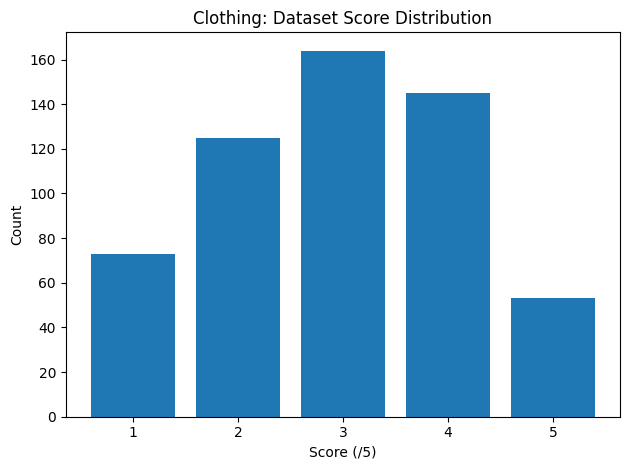

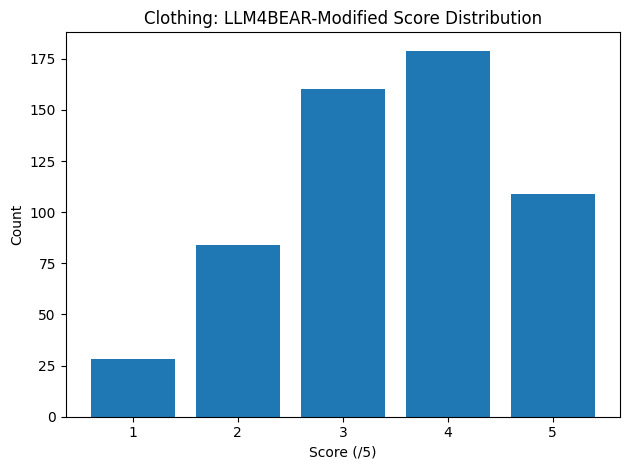

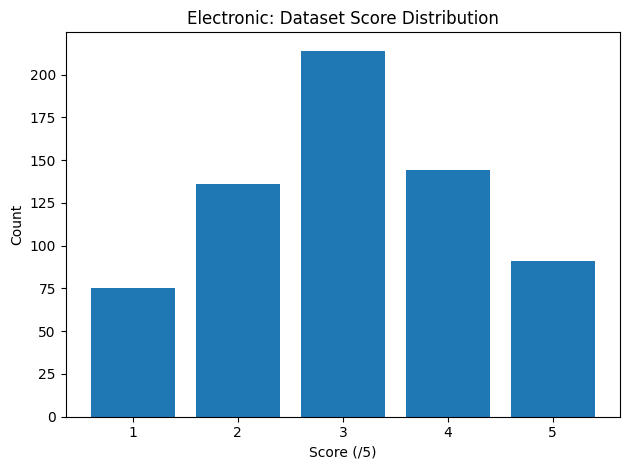

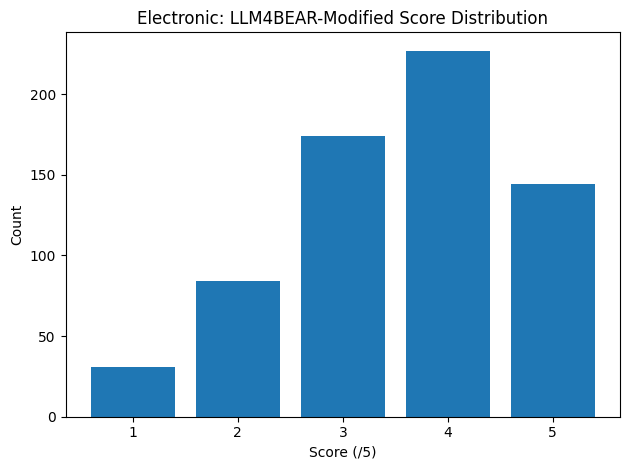

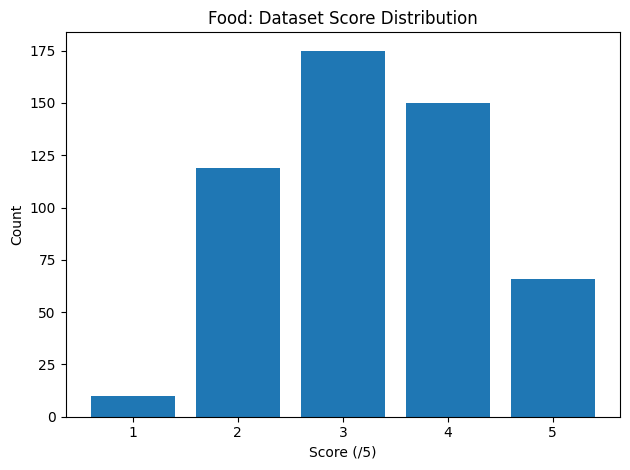

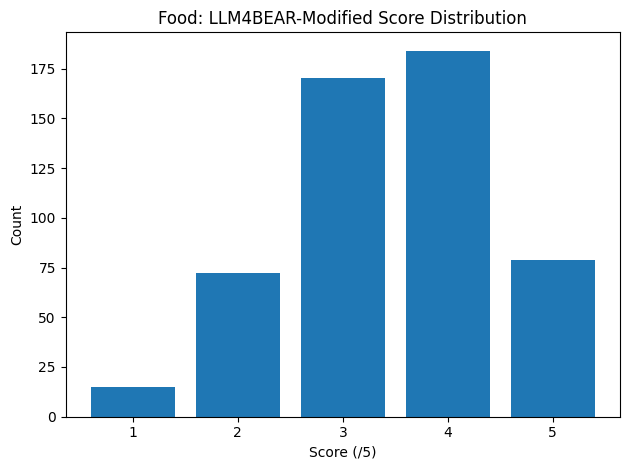

time: 987 ms (started: 2026-01-06 20:08:50 +00:00)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def clean_1d(arr):
    a = np.array(arr, dtype=float)
    a = a[np.isfinite(a)]
    a = np.rint(a).astype(int)
    a = a[(a >= 1) & (a <= 5)]
    return a

def plot_discrete_hist(arr, title):
    xs = [1,2,3,4,5]
    counts = [(arr == k).sum() for k in xs]
    plt.figure()
    plt.bar(xs, counts)
    plt.xticks(xs)
    plt.xlabel("Score (/5)")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

cl_u = clean_1d(clothing_unmodded_score_collection)
cl_m = clean_1d(clothing_modded_score_collection)
el_u = clean_1d(electronic_unmodded_score_collection)
el_m = clean_1d(electronic_modded_score_collection)
fo_u = clean_1d(food_unmodded_score_collection)
fo_m = clean_1d(food_modded_score_collection)

plot_discrete_hist(cl_u, "Clothing: Dataset Score Distribution")
plot_discrete_hist(cl_m, "Clothing: LLM4BEAR-Modified Score Distribution")
plot_discrete_hist(el_u, "Electronic: Dataset Score Distribution")
plot_discrete_hist(el_m, "Electronic: LLM4BEAR-Modified Score Distribution")
plot_discrete_hist(fo_u, "Food: Dataset Score Distribution")
plot_discrete_hist(fo_m, "Food: LLM4BEAR-Modified Score Distribution")


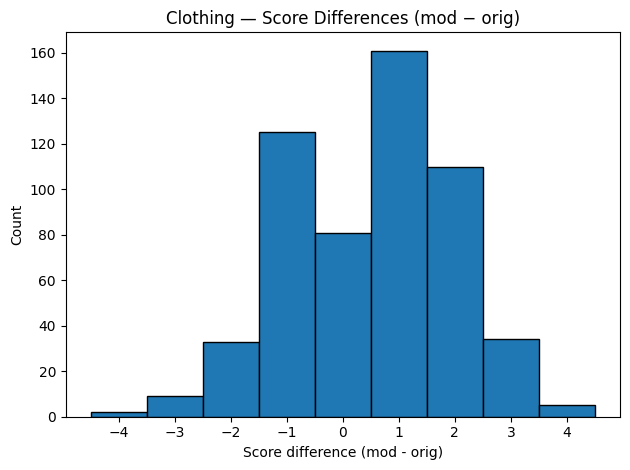

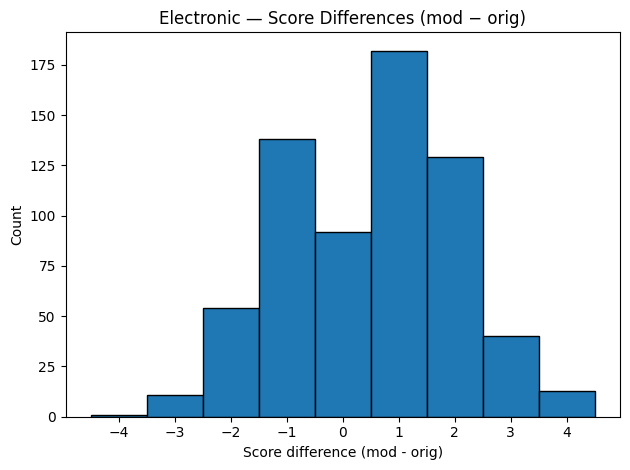

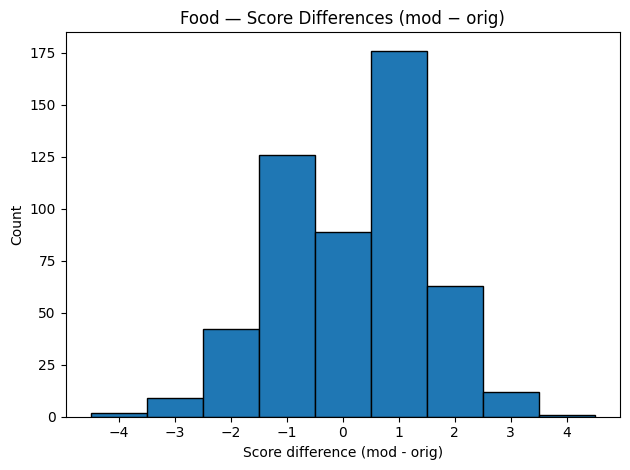

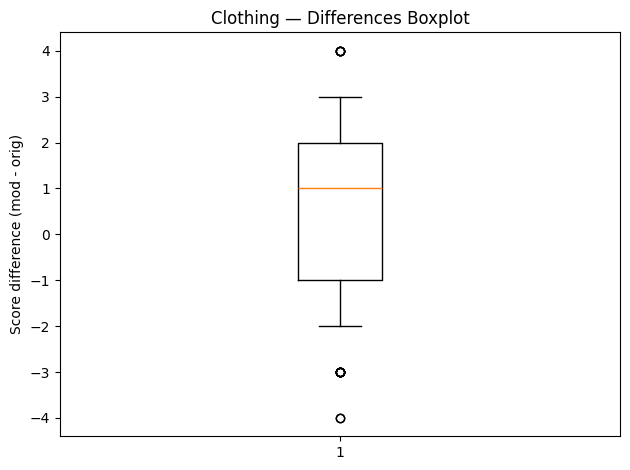

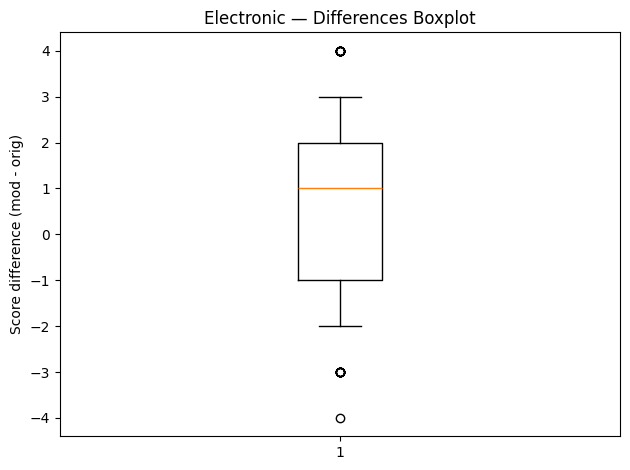

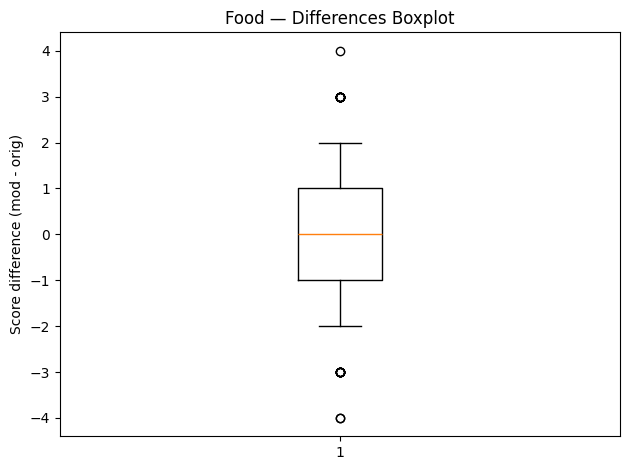

Clothing: n=560, mean=0.495, sd=1.477, counts={-4: 2, -3: 9, -2: 33, -1: 125, 0: 81, 1: 161, 2: 110, 3: 34, 4: 5}
Electronic: n=660, mean=0.498, sd=1.544, counts={-4: 1, -3: 11, -2: 54, -1: 138, 0: 92, 1: 182, 2: 129, 3: 40, 4: 13}
Food: n=520, mean=0.187, sd=1.346, counts={-4: 2, -3: 9, -2: 42, -1: 126, 0: 89, 1: 176, 2: 63, 3: 12, 4: 1}
time: 939 ms (started: 2026-01-06 20:08:59 +00:00)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Clean helpers (drop NaNs, coerce to float)
def clean(x):
    a = np.array(x, dtype=float)
    return a[np.isfinite(a)]

# Histogram (integer-centered bins)
def plot_diff_hist(diffs, title):
    diffs = clean(diffs)
    bins = np.arange(-4.5, 5.5, 1.0)  # centers at -4,-3,...,+4
    plt.figure()
    plt.hist(diffs, bins=bins, edgecolor='black')  # no custom colors/styles
    plt.xticks(range(-4, 5))
    plt.xlabel("Score difference (mod - orig)")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Boxplot (optional): separate figure, one plot only
def plot_diff_box(diffs, title):
    diffs = clean(diffs)
    plt.figure()
    plt.boxplot(diffs, vert=True, whis=(5,95), showfliers=True)
    plt.ylabel("Score difference (mod - orig)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- Run: one figure per plot ---
plot_diff_hist(clothing_differences,   "Clothing — Score Differences (mod − orig)")
plot_diff_hist(electronic_differences, "Electronic — Score Differences (mod − orig)")
plot_diff_hist(food_differences,       "Food — Score Differences (mod − orig)")

# Optional: boxplots (each in its own figure)
plot_diff_box(clothing_differences,   "Clothing — Differences Boxplot")
plot_diff_box(electronic_differences, "Electronic — Differences Boxplot")
plot_diff_box(food_differences,       "Food — Differences Boxplot")

# Quick numeric summary you can print alongside
def summarize(diffs, label):
    d = clean(diffs)
    counts = {k: int(np.sum(d == k)) for k in range(-4, 5)}
    mean = float(np.mean(d)) if d.size else np.nan
    sd   = float(np.std(d, ddof=1)) if d.size > 1 else np.nan
    print(f"{label}: n={d.size}, mean={mean:.3f}, sd={sd:.3f}, counts={counts}")

summarize(clothing_differences,   "Clothing")
summarize(electronic_differences, "Electronic")
summarize(food_differences,       "Food")


In [12]:
import numpy as np
from math import sqrt
from scipy.stats import ttest_1samp, t
from scipy.stats import wilcoxon  # nonparametric confirm

def ttest_diffs(name, diffs):
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]  # drop NaNs
    n = d.size
    mean = d.mean()
    sd   = d.std(ddof=1) if n > 1 else np.nan
    se   = sd / sqrt(n)   if n > 1 else np.nan

    # two-sided t-test around 0, then convert to one-sided (>0)
    tstat, p_two = ttest_1samp(d, 0.0)
    p_one = (p_two / 2) if mean > 0 else 1.0

    # 95% CI for the mean (Student t)
    df = n - 1
    tcrit = t.ppf(0.975, df) if df > 0 else np.nan
    ci_lo = mean - tcrit * se if se == se else np.nan
    ci_hi = mean + tcrit * se if se == se else np.nan

    # Effect size (Cohen's d and Hedges' g)
    d_cohen = mean / sd if sd and sd > 0 else np.nan
    g_hedges = d_cohen * (1 - (3 / (4*df - 1))) if df > 1 else d_cohen

    # Nonparametric confirmation (one-sided Wilcoxon > 0)
    try:
        _, p_wilcoxon = wilcoxon(d, zero_method="pratt", alternative="greater")
    except Exception:
        p_wilcoxon = np.nan

    print(f"{name}: n={n}, meanΔ={mean:.3f}, sd={sd:.3f}, "
          f"t={tstat:.3f}, p_one-sided={p_one:.3g}, "
          f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}], "
          f"Cohen d={d_cohen:.2f}, Hedges g={g_hedges:.2f}, "
          f"Wilcoxon p={p_wilcoxon:.3g}")

# Call it on your arrays:
ttest_diffs("Clothing",   clothing_differences)
ttest_diffs("Electronic", electronic_differences)
ttest_diffs("Food",       food_differences)


Clothing: n=560, meanΔ=0.495, sd=1.477, t=7.923, p_one-sided=6.28e-15, 95% CI [0.372, 0.617], Cohen d=0.33, Hedges g=0.33, Wilcoxon p=1.78e-14
Electronic: n=660, meanΔ=0.498, sd=1.544, t=8.294, p_one-sided=3.08e-16, 95% CI [0.380, 0.616], Cohen d=0.32, Hedges g=0.32, Wilcoxon p=3.87e-15
Food: n=520, meanΔ=0.187, sd=1.346, t=3.159, p_one-sided=0.000837, 95% CI [0.071, 0.303], Cohen d=0.14, Hedges g=0.14, Wilcoxon p=0.000396
time: 1.62 s (started: 2026-01-06 20:09:07 +00:00)


In [13]:
import numpy as np
import pandas as pd

def score_counts(arr):
    return pd.Series({k: int(np.sum(arr==k)) for k in [1,2,3,4,5]})

def before_after_delta(unmod, mod, label):
    c_u = score_counts(unmod)
    c_m = score_counts(mod)
    delta = (c_m - c_u).rename("Δ count")
    out = pd.concat([c_u.rename("before"), c_m.rename("after"), delta], axis=1)
    out.index.name = f"{label} score"
    print(out, "\n")

# Example calls (plug in the cleaned 1D arrays you plotted):
before_after_delta(cl_u, cl_m, "Clothing")
before_after_delta(el_u, el_m, "Electronic")
before_after_delta(fo_u, fo_m, "Food")


                before  after  Δ count
Clothing score                        
1                   73     28      -45
2                  125     84      -41
3                  164    160       -4
4                  145    179       34
5                   53    109       56 

                  before  after  Δ count
Electronic score                        
1                     75     31      -44
2                    136     84      -52
3                    214    174      -40
4                    144    227       83
5                     91    144       53 

            before  after  Δ count
Food score                        
1               10     15        5
2              119     72      -47
3              175    170       -5
4              150    184       34
5               66     79       13 

time: 61.1 ms (started: 2026-01-06 20:09:12 +00:00)


In [14]:
import numpy as np
from itertools import chain

def clean(a):
    a = np.array(a, dtype=float)
    a = a[np.isfinite(a)]
    a = np.rint(a).astype(int)
    return a[(a>=1)&(a<=5)]

def metrics(unmod_lists, mod_lists, label):
    u = clean(list(chain.from_iterable(unmod_lists)))
    m = clean(list(chain.from_iterable(mod_lists)))
    n = min(len(u), len(m)); u, m = u[:n], m[:n]
    valid = ~np.isnan(u) & ~np.isnan(m)
    u, m = u[valid], m[valid]

    # 1) 4+ coverage uplift
    cov4_u = np.mean(u >= 4)
    cov4_m = np.mean(m >= 4)
    cov4_delta = cov4_m - cov4_u

    # 2) headroom-adjusted non-tie win rate (higher is better)
    headroom = u <= 4
    cmp_idx = headroom
    imp = (m > u)[cmp_idx]
    tie = (m == u)[cmp_idx]
    ha_den = max(int(np.sum(cmp_idx)) - int(np.sum(tie)), 1)
    ha_win = int(np.sum(imp)) / ha_den

    # 3) mean score lift
    delta = m - u
    d_mean = float(np.mean(delta))
    d_sd = float(np.std(delta, ddof=1))
    from math import sqrt
    se = d_sd / sqrt(len(delta)) if len(delta)>1 else float("nan")
    z = 1.96
    ci_lo, ci_hi = d_mean - z*se, d_mean + z*se

    print(f"{label}: 4+ coverage +{cov4_delta*100:.1f} pts "
          f"(orig {cov4_u*100:.1f}%, mod {cov4_m*100:.1f}%), "
          f"HA win% {ha_win*100:.1f}%, "
          f"Δmean {d_mean:.2f} [{ci_lo:.2f}, {ci_hi:.2f}]")


time: 7.09 ms (started: 2026-01-06 20:09:19 +00:00)


In [15]:
metrics(clothing_unmodded_scores,   clothing_modded_scores,   "Clothing")
metrics(electronic_unmodded_scores, electronic_modded_scores, "Electronic")
metrics(food_unmodded_scores,       food_modded_scores,       "Food")


Clothing: 4+ coverage +16.1 pts (orig 35.4%, mod 51.4%), HA win% 70.3%, Δmean 0.49 [0.37, 0.62]
Electronic: 4+ coverage +20.6 pts (orig 35.6%, mod 56.2%), HA win% 73.8%, Δmean 0.50 [0.38, 0.62]
Food: 4+ coverage +9.0 pts (orig 41.5%, mod 50.6%), HA win% 67.0%, Δmean 0.19 [0.07, 0.30]
time: 6.34 ms (started: 2026-01-06 20:09:25 +00:00)


In [16]:
import numpy as np
from itertools import chain

# set if higher numbers mean better scores
HIGHER_IS_BETTER = True

def _to_float_array(x):
    a = np.array(list(chain.from_iterable(x)), dtype=float)
    return a

def eval_category(unmod_lists, mod_lists, *, label="", higher_is_better=True):
    u = _to_float_array(unmod_lists)
    m = _to_float_array(mod_lists)
    n = min(len(u), len(m))
    u, m = u[:n], m[:n]

    # valid pairs only
    valid = ~np.isnan(u) & ~np.isnan(m)
    u, m = u[valid], m[valid]

    # outcomes
    if higher_is_better:
        improved = (m > u)
        worsened = (m < u)
        ties     = (m == u)
    else:
        improved = (m < u)
        worsened = (m > u)
        ties     = (m == u)

    n_valid    = int(valid.sum())
    n_ties     = int(ties.sum())
    n_nonties  = n_valid - n_ties
    n_improved = int(improved.sum())
    n_worsened = int(worsened.sum())

    # --- exact binomial test on non-ties ---
    try:
        from scipy.stats import binomtest
        btest = binomtest(n_improved, n_nonties, 0.5, alternative="greater")
        p_binom = btest.pvalue
        phat = n_improved / n_nonties if n_nonties else np.nan
        # Wilson CI for phat
        try:
            from statsmodels.stats.proportion import proportion_confint
            ci_low, ci_high = proportion_confint(n_improved, n_nonties, alpha=0.05, method="wilson")
        except Exception:
            # Manual Wilson (approx)
            import math
            if n_nonties:
                z = 1.959963984540054
                p = phat
                denom = 1 + z*z/n_nonties
                center = (p + z*z/(2*n_nonties))/denom
                half = z*np.sqrt((p*(1-p)/n_nonties) + (z*z/(4*n_nonties*n_nonties))) / denom
                ci_low, ci_high = center - half, center + half
            else:
                ci_low = ci_high = np.nan
    except Exception:
        p_binom = np.nan
        phat = n_improved / n_nonties if n_nonties else np.nan
        ci_low = ci_high = np.nan

    # --- paired delta analyses (m - u) ---
    deltas = m - u if higher_is_better else u - m  # “positive = improved” by convention
    delta_mean = float(np.nanmean(deltas)) if deltas.size else np.nan
    delta_std  = float(np.nanstd(deltas, ddof=1)) if deltas.size > 1 else np.nan

    try:
        from scipy.stats import ttest_rel, wilcoxon
        # Use only non-NaN pairs (already filtered)
        t_stat, p_t = ttest_rel(m, u, alternative="greater") if higher_is_better else ttest_rel(u, m, alternative="greater")
        # Wilcoxon (requires at least one nonzero delta)
        nz = deltas[deltas != 0]
        if nz.size >= 1:
            w_stat, p_w = wilcoxon(nz, zero_method="pratt", alternative="greater")
        else:
            w_stat, p_w = np.nan, np.nan
    except Exception:
        t_stat = p_t = w_stat = p_w = np.nan

    # Pretty print
    pct_inc_excl_ties = 100.0 * phat if n_nonties else 0.0
    pct_inc_incl_ties = 100.0 * (n_improved / n_valid) if n_valid else 0.0
    print(f"{label or '(category)'}")
    print(f"  valid={n_valid}, improved={n_improved}, worsened={n_worsened}, ties={n_ties}")
    print(f"  % improved (exclude ties): {pct_inc_excl_ties:.1f}%  "
          f"(Wilson 95% CI [{ci_low:.3f}, {ci_high:.3f}], binom p={p_binom:.3g})")
    print(f"  % improved (include ties): {pct_inc_incl_ties:.1f}%")
    print(f"  Δ = mean(m - u) if higher-better else (u - m): mean={delta_mean:.4g}, sd={delta_std:.4g}")
    print(f"  paired t (one-sided): p={p_t:.3g} | Wilcoxon (one-sided): p={p_w:.3g}")
    return {
        "valid": n_valid, "ties": n_ties, "non_ties": n_nonties,
        "improved": n_improved, "worsened": n_worsened,
        "phat": phat, "ci_low": ci_low, "ci_high": ci_high, "p_binom": p_binom,
        "delta_mean": delta_mean, "delta_sd": delta_std, "p_t": p_t, "p_w": p_w
    }

# EXAMPLES (using your already-built lists):
eval_category(clothing_unmodded_scores,   clothing_modded_scores,   label="Clothing",   higher_is_better=HIGHER_IS_BETTER)
eval_category(electronic_unmodded_scores, electronic_modded_scores, label="Electronic", higher_is_better=HIGHER_IS_BETTER)
eval_category(food_unmodded_scores,       food_modded_scores,       label="Food",       higher_is_better=HIGHER_IS_BETTER)


Clothing
  valid=560, improved=310, worsened=169, ties=81
  % improved (exclude ties): 64.7%  (Wilson 95% CI [0.603, 0.689], binom p=5.87e-11)
  % improved (include ties): 55.4%
  Δ = mean(m - u) if higher-better else (u - m): mean=0.4946, sd=1.477
  paired t (one-sided): p=6.28e-15 | Wilcoxon (one-sided): p=5.38e-15
Electronic
  valid=660, improved=364, worsened=204, ties=92
  % improved (exclude ties): 64.1%  (Wilson 95% CI [0.601, 0.679], binom p=9.38e-12)
  % improved (include ties): 55.2%
  Δ = mean(m - u) if higher-better else (u - m): mean=0.4985, sd=1.544
  paired t (one-sided): p=3.08e-16 | Wilcoxon (one-sided): p=1.58e-15
Food
  valid=520, improved=252, worsened=179, ties=89
  % improved (exclude ties): 58.5%  (Wilson 95% CI [0.538, 0.630], binom p=0.000255)
  % improved (include ties): 48.5%
  Δ = mean(m - u) if higher-better else (u - m): mean=0.1865, sd=1.346
  paired t (one-sided): p=0.000837 | Wilcoxon (one-sided): p=0.000663


{'valid': 520,
 'ties': 89,
 'non_ties': 431,
 'improved': 252,
 'worsened': 179,
 'phat': 0.5846867749419954,
 'ci_low': 0.5376164804073655,
 'ci_high': 0.6302607965155358,
 'p_binom': np.float64(0.0002548674780029295),
 'delta_mean': 0.18653846153846154,
 'delta_sd': 1.3464473837787791,
 'p_t': np.float64(0.0008370386245445582),
 'p_w': np.float64(0.0006629113295168636)}

time: 318 ms (started: 2026-01-06 20:09:33 +00:00)
